In [1]:
# Importamos librerías necesarias.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Layer, Input
from tensorflow.keras.optimizers import RMSprop, Adam

import matplotlib.pyplot as plt
import math as mt
import numpy as np

In [2]:
# Definimos la capa del polinomio de grado 3.
class polinomio_3(Layer):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)
    # Colocamos los coeficientes que serán entrenables.
    self.a0 = self.add_weight(name="a0", initializer="random_normal", trainable=True)
    self.a1 = self.add_weight(name="a1", initializer="random_normal", trainable=True)
    self.a2 = self.add_weight(name="a2", initializer="random_normal", trainable=True)
    self.a3 = self.add_weight(name="a3", initializer="random_normal", trainable=True)

  def call(self, inputs):
    return self.a0 + self.a1*inputs + self.a2*tf.pow(inputs,2) + self.a3*tf.pow(inputs,3)

In [3]:
# La función a ajustar.
f = lambda x: np.cos(2*x)

# Generamos datos de entrenamiento.
x = np.linspace(-1,1,200).reshape(-1,1).astype(np.float32)
y_train = f(x).astype(np.float32)

# Construimos el modelo con una sola capa del polinomio.
model = Sequential([polinomio_3(input_shape=(1,))])

# Compilamos.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")

/tmp/ipython-input-1451790795.py:4: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# Enbtrenamos.
history = model.fit(x, y_train, epochs=500, verbose=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


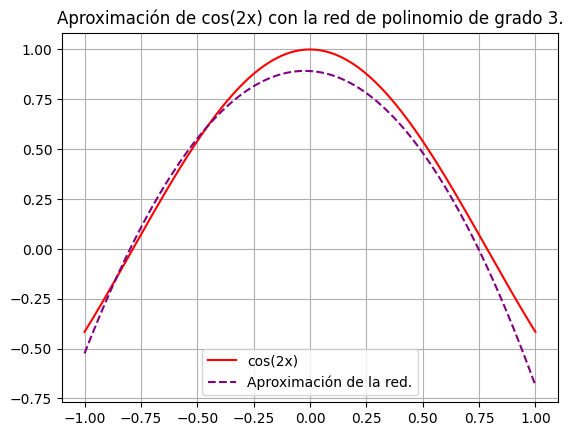

Coeficientes determinados:
a0: 0.8918716 a1: -0.067971416 a2: -1.4962968 a3: -0.012421342


In [5]:
# Gráficamos.
plt.plot(x, y_train, label="cos(2x)", color='r')
plt.plot(x, model.predict(x), label="Aproximación de la red.", color='purple', linestyle="dashed")
plt.legend()
plt.grid()
plt.title("Aproximación de cos(2x) con la red de polinomio de grado 3.")
plt.show()

# Los coeficientes determinados por la red.
coef = model.layers[0]
print("Coeficientes determinados:")
print("a0:", coef.a0.numpy(), "a1:", coef.a1.numpy(), "a2:", coef.a2.numpy(), "a3:", coef.a3.numpy())